In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import pickle

In [2]:
#Looking at the columns + previous knowledge about dataset, it can be split into 2 'chunks' - records with violation and records without. 
#Perform TS analysis on both of these
data = pd.read_csv("..\\Dataset\\NYC_Drinking_Water_Tank_Inspections_and_Audits_Compliance_Results_20251203.csv")
print(data.columns)
data.shape

Index(['BIN', 'House #', 'Street Name', 'Zip_code', 'Borough', 'Status',
       'Number of DWT', 'Activity_Type', 'Activity_Year', 'Violation_Code',
       'Law_Section', 'Violation_Text', 'Compliance_Year',
       'Date_of_Occurrence', 'Summons_Number', 'BBL', 'Longitude', 'Latitude',
       'Community_Board', 'Council_District', 'Census_Tract', 'NTA_Code'],
      dtype='str')


(16562, 22)

In [3]:
violation_data = data[data['Violation_Code'].notna()]
nonViolation_data = data[data['Violation_Code'].isna()]

print(violation_data.shape)
print(nonViolation_data.shape)

(1412, 22)
(15150, 22)


In [4]:
#Drop NaN columns from the nonViolation data (violation info column)
nonViolation_data = nonViolation_data.drop(columns = ['Violation_Code', 'Law_Section', 'Violation_Text', 'Compliance_Year', 'Date_of_Occurrence', 'Summons_Number'])
nonViolation_data.columns

Index(['BIN', 'House #', 'Street Name', 'Zip_code', 'Borough', 'Status',
       'Number of DWT', 'Activity_Type', 'Activity_Year', 'BBL', 'Longitude',
       'Latitude', 'Community_Board', 'Council_District', 'Census_Tract',
       'NTA_Code'],
      dtype='str')

In [5]:
#Understanding how the date info is stored for violation data
viol = violation_data.copy()
viol['Date_of_Occurrence'] = pd.to_datetime(viol['Date_of_Occurrence'], errors='coerce')
viol = viol.dropna(subset=['Date_of_Occurrence'])
viol = viol.sort_values('Date_of_Occurrence')

viol['Year'] = viol['Date_of_Occurrence'].dt.year
viol['Month'] = viol['Date_of_Occurrence'].dt.month
viol['YearMonth'] = viol['Date_of_Occurrence'].dt.to_period('M')

print(f"{viol['Date_of_Occurrence'].min().date()} to {viol['Date_of_Occurrence'].max().date()}")

2021-11-24 to 2024-03-11


In [6]:
#Splitting data into a month-wise, last-compliance, and borough-wise TSs
#Note that compliance year likely represents the last time that the DWT at the building passed an inspection
viol_monthly = (viol.groupby('YearMonth').size().rename('violation_count'))
viol_monthly.index = viol_monthly.index.to_timestamp()

viol['Compliance_Lag'] = (pd.to_numeric(viol['Activity_Year']-pd.to_numeric(viol['Compliance_Year'], errors='coerce'),   errors='coerce'))
viol_lag_monthly = (viol.groupby('YearMonth')['Compliance_Lag'].mean().rename('avg_compliance_lag'))
viol_lag_monthly.index = viol_lag_monthly.index.to_timestamp()

borough_monthly = (viol.groupby(['YearMonth', 'Borough']).size().unstack(fill_value=0))
borough_monthly.index = borough_monthly.index.to_timestamp()  

In [7]:
#Forcing consistent frequency via interpolation
viol_monthly     = viol_monthly.asfreq('MS').interpolate(method='time')
viol_lag_monthly = viol_lag_monthly.asfreq('MS').interpolate(method='time')

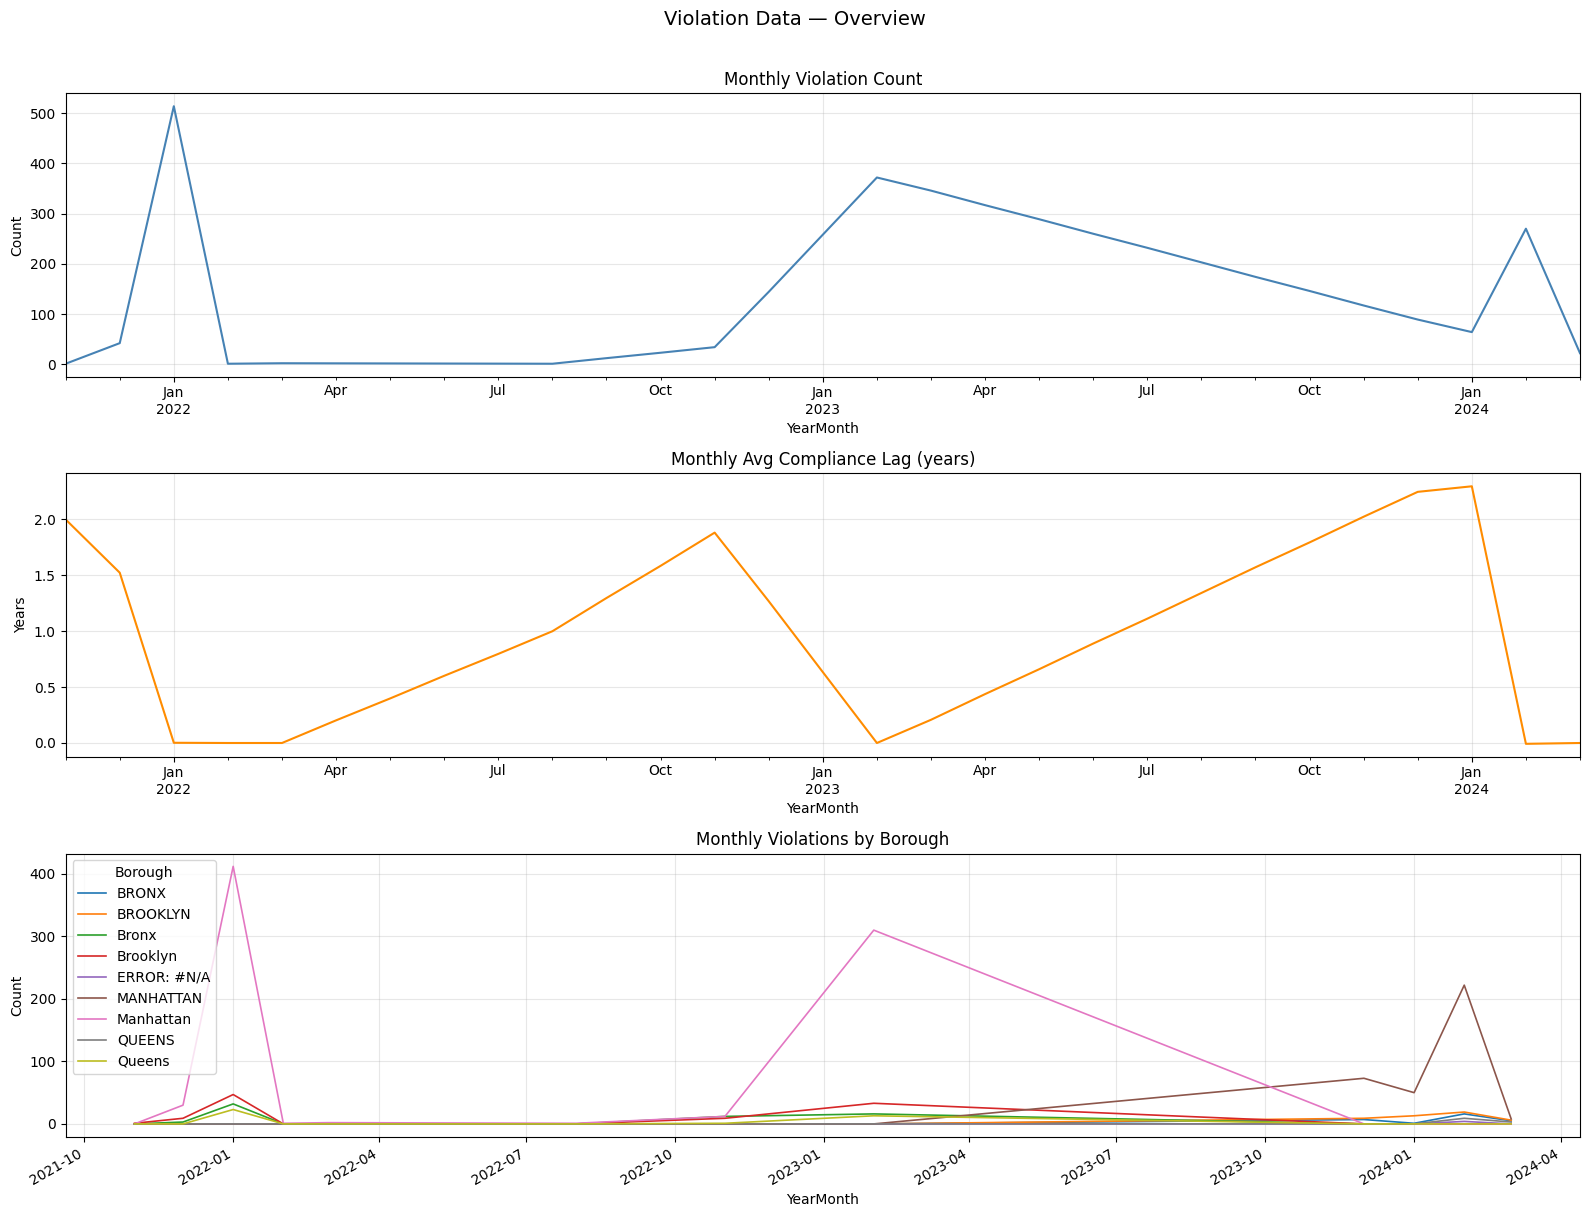

In [8]:
#Plotting the 3 TSs
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

viol_monthly.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Monthly Violation Count')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

viol_lag_monthly.plot(ax=axes[1], color='darkorange', linewidth=1.5)
axes[1].set_title('Monthly Avg Compliance Lag (years)')
axes[1].set_ylabel('Years')
axes[1].grid(True, alpha=0.3)

borough_monthly.plot(ax=axes[2], linewidth=1.2)
axes[2].set_title('Monthly Violations by Borough')
axes[2].set_ylabel('Count')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Violation Data — Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
def decomposition(series, period):
    s = series.dropna()
    decomp_add = seasonal_decompose(s, model='additive', period=period)
    
    decomp_mul = None
    #Check to ensure that multiplicative decomposition is only done where permissible (+ve values only)
    if (s > 0).all():
        decomp_mul = seasonal_decompose(s, model='multiplicative', period=period)

    return {
        'original':     s,
        'detrended':    s - decomp_add.trend,
        'deseasonal':   s - decomp_add.seasonal,
        'differenced':  s.diff().dropna(),
        'add':          decomp_add,
        'mul':          decomp_mul
    }

def plot_decomposed(components, name):
    fig, axes = plt.subplots(4, 2 if components['mul'] else 1, figsize=(15, 12), sharex=True)
    fig.suptitle(f'Decomposition results for {name}', fontsize=16)
    
    models = [('add', 0)]
    if components['mul']:
        models.append(('mul', 1))

    for model_key, col_idx in models:
        res = components[model_key]
        parts = [res.observed, res.trend, res.seasonal, res.resid]
        titles = ['Observed', 'Trend', 'Seasonal', 'Residual']
        colors = ['steelblue', 'darkorange', 'green', 'red']

        for row_idx, (data, title, color) in enumerate(zip(parts, titles, colors)):
            ax = axes[row_idx, col_idx] if components['mul'] else axes[row_idx]
            
            data.plot(ax=ax, color=color, lw=1.5)
            ax.set_title(f"{model_key.capitalize()} {title}")
            ax.grid(axis='y', alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

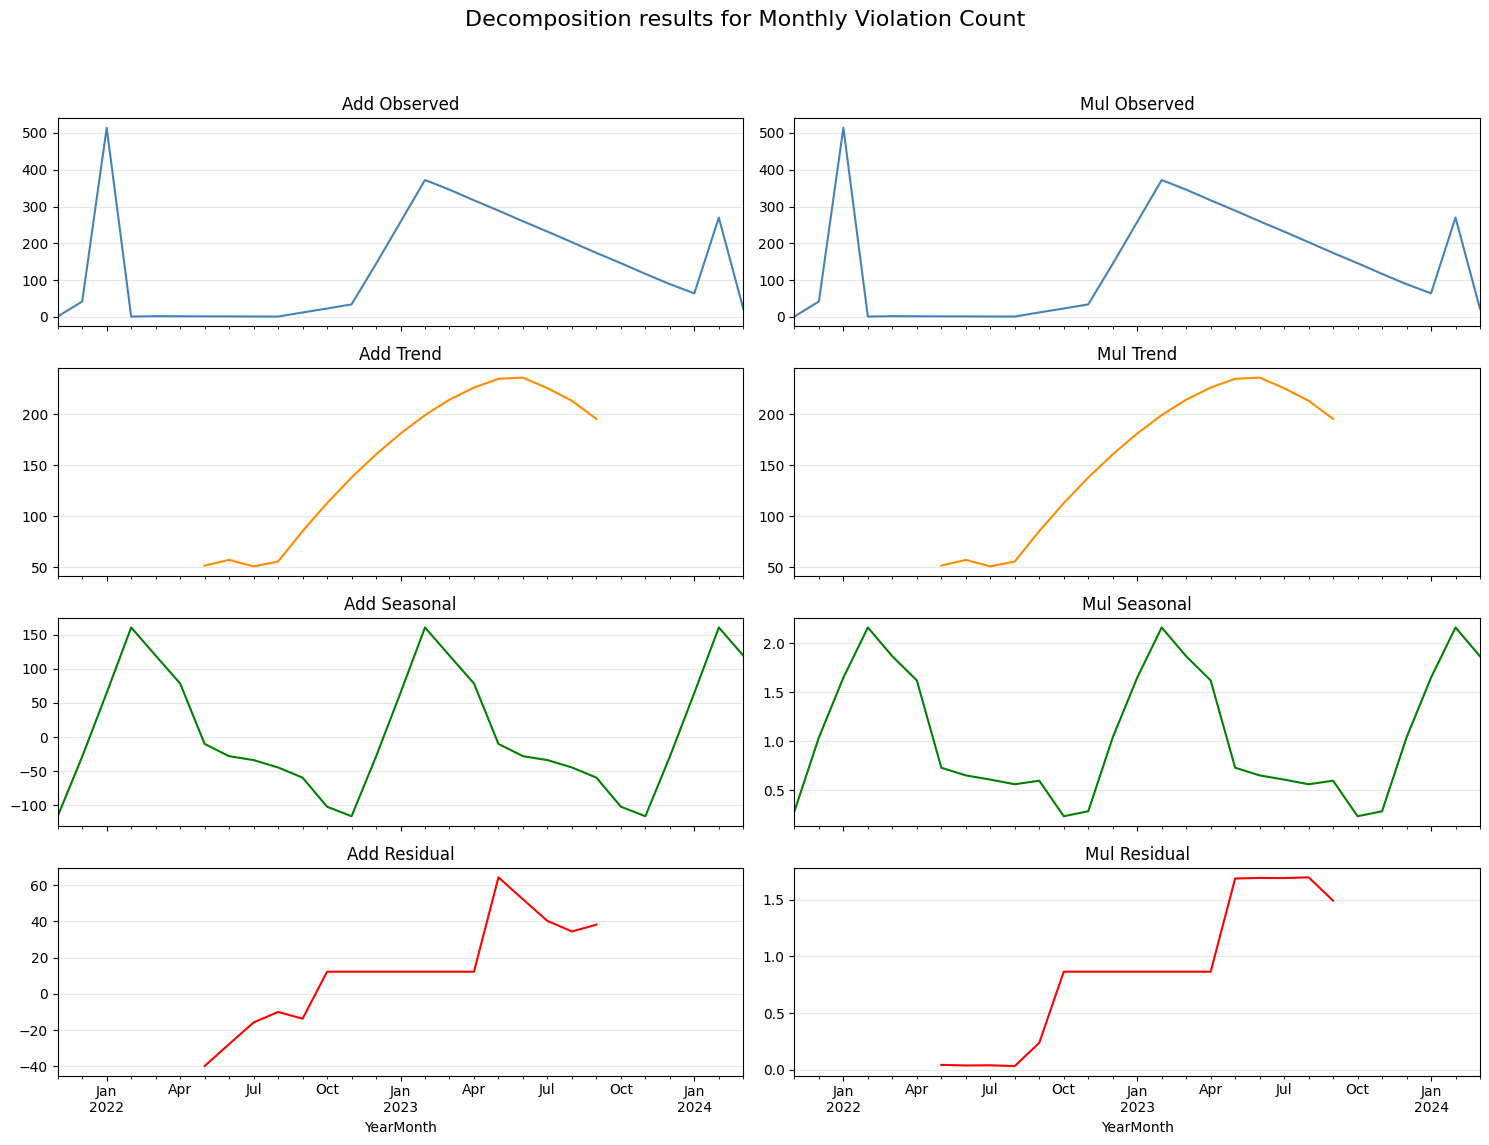

In [10]:
viol_info = decomposition(viol_monthly, period=12)
plot_decomposed(viol_info, "Monthly Violation Count")

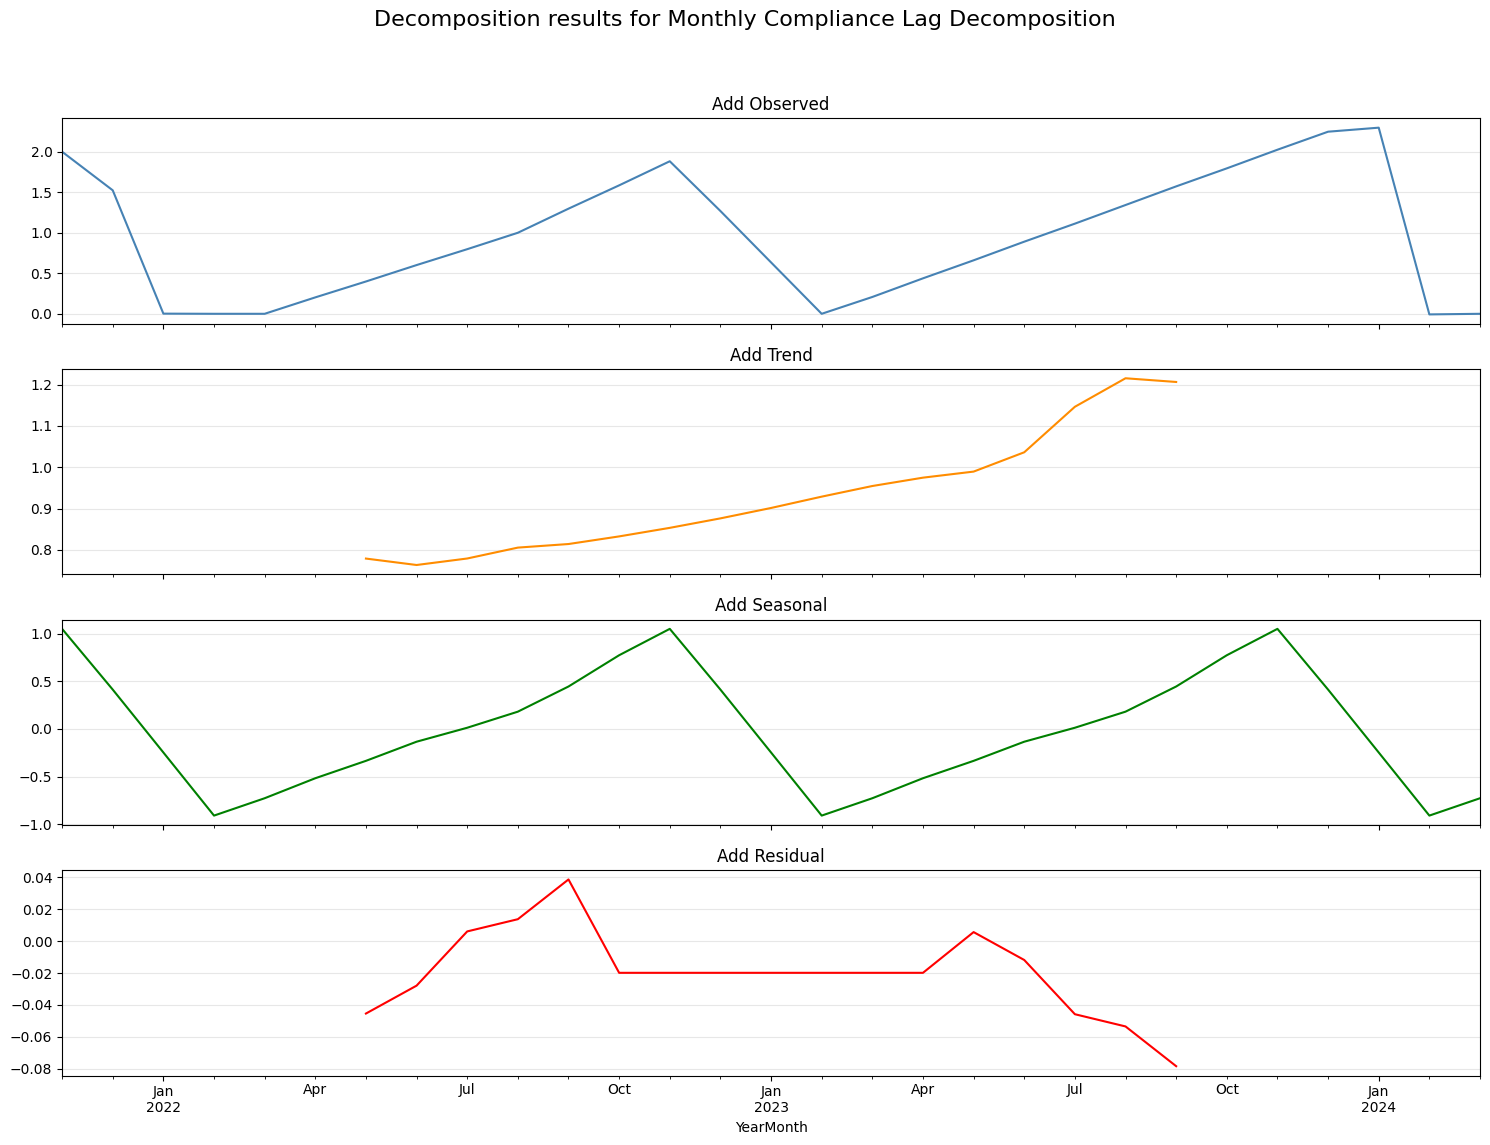

In [12]:
lag_info = decomposition(viol_lag_monthly, period=12)
plot_decomposed(lag_info, "Monthly Compliance Lag Decomposition")

In [13]:
#Understanding how the date info is stored for non-violation data
nonv = nonViolation_data.copy()
nonv['Activity_Year'] = pd.to_datetime(nonv['Activity_Year'], format='%Y', errors='coerce')
nonv = nonv.dropna(subset=['Activity_Year'])
nonv = nonv.sort_values('Activity_Year')

nonv['Year'] = nonv['Activity_Year'].dt.year

print(f"{nonv['Activity_Year'].min().date()} to {nonv['Activity_Year'].max().date()}")

2021-01-01 to 2024-01-01


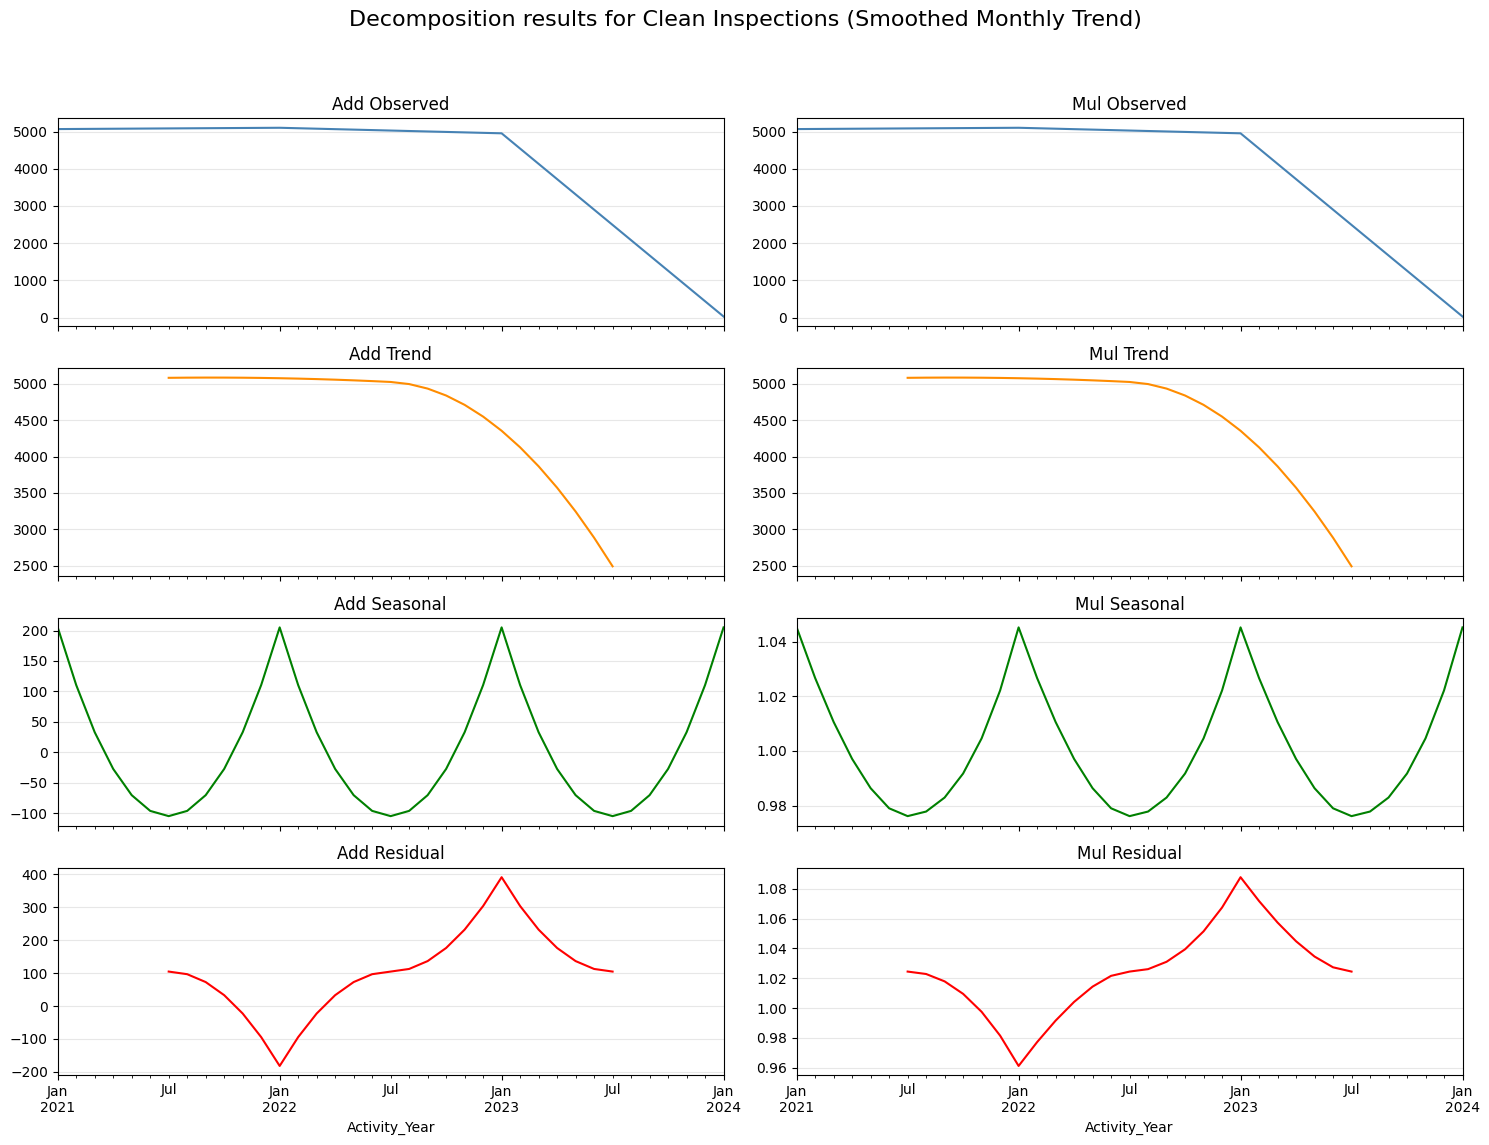

In [14]:
#Clearly, there is simply not the resolution required to perform any analysis on inspection data.
nonv_monthly = nonv.groupby('Activity_Year').size().rename('inspection_count')
nonv_monthly = nonv_monthly.asfreq('MS')
nonv_monthly_smoothed = nonv_monthly.interpolate(method='linear')

nonv_info = decomposition(nonv_monthly_smoothed, period=12)
plot_decomposed(nonv_info, 'Clean Inspections (Smoothed Monthly Trend)')

In [15]:
with open("..\\Dataset\\viol_analysis_results.pkl", 'wb') as f:
    pickle.dump(viol_info, f)

with open("..\\Dataset\\viol_analysis_results.pkl", 'wb') as f:
    pickle.dump(lag_info, f)